# 01. FOM And ROSE Basics

This notebook establishes the baseline workflow:

1. use ROSE as the full-order model (FOM) solver for neutron scattering,
2. train ROSE's standard reduced-basis/Galerkin/EIM emulator,
3. compare FOM and ROSE ROM wavefunctions and differential cross sections.

The notebook uses the public PyPI package `nuclear-rose`, imported as
`rose`.  No local ROSE source checkout is required.

The import `from lrom_demo import rose_rom` loads a small helper module
shipped with this folder.  It is not part of ROSE itself; it just wraps
repeated setup steps such as building the calcium scattering problem,
training the standard ROSE emulator, and making benchmark plots.  The
scientific computations are still done by `rose`.

In these clean notebooks we keep the optional ROSE snapshot scaling
turned off (`scale=False`) unless explicitly stated otherwise.  This
means reduced bases and least-squares projections are built from raw
FOM wavefunctions.

In [2]:
!pip install nuclear-rose

  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached babel-2.18.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached jupyterlab_pygments-0.3.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached nbclient-0.10.4-py3-none-any.whl.metadata (8.3 kB)
  Using cached pandocfilters-1.5.1-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached tinycss2-1.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached attrs-26.1.0-py3-none-any

In [3]:
from pathlib import Path
import importlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "lrom_demo").exists() and (ROOT.parent / "lrom_demo").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT = ROOT / "outputs" / Path(__file__).stem if "__file__" in globals() else ROOT / "outputs" / "notebook_outputs"
OUT.mkdir(parents=True, exist_ok=True)

import rose
from lrom_demo import rose_rom
rose_rom = importlib.reload(rose_rom)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("ROSE imported from:", rose.__file__)
print("output folder:", OUT)

ImportError: cannot import name '_slice' from 'numpy._core.umath' (/Users/Kitkat/miniconda3/envs/scienv/lib/python3.11/site-packages/numpy/_core/umath.py)

## Scientific Setup

We start with the same calcium neutron-scattering setup used throughout
the exploratory work.  The helper object below is intentionally modest
so the notebook runs quickly; increase `n_train`, `n_phi`, `n_U`, and
`l_max` for publication-quality comparisons.

In [2]:
config = rose_rom.Phase2Config(
    n_train=40,
    n_phi=4,
    n_U=8,
    l_max=10,
    n_mesh=900,
    n_angles=160,
)
config

Phase2Config(target=(40, 20), projectile=(1, 0), e_lab=14.1, l_max=10, n_train=40, n_test=12, parameter_scale=0.2, n_phi=4, n_U=8, seed_train=20260515, seed_test=20260516, rk_tols=(1e-09, 1e-09), s_0_factor=18.84955592153876, domain_min=1e-08, domain_max=25.132741228718345, n_mesh=900, n_angles=160)

## Train The Standard ROSE Emulator

In [3]:
t0 = time.perf_counter()
problem = rose_rom.build_training_problem(config)
emulator = rose_rom.train_emulator(config, problem)
print(f"ROSE training seconds: {time.perf_counter() - t0:.2f}")
print("central alpha:", np.array2string(problem["alpha_central"], precision=4))


  0%|          | 0/11 [00:00<?, ?it/s]


  9%|▉         | 1/11 [00:02<00:26,  2.66s/it]


 18%|█▊        | 2/11 [00:06<00:28,  3.19s/it]


 27%|██▋       | 3/11 [00:09<00:24,  3.09s/it]


 36%|███▋      | 4/11 [00:11<00:19,  2.86s/it]

...


 82%|████████▏ | 9/11 [00:22<00:04,  2.19s/it]


 91%|█████████ | 10/11 [00:24<00:02,  2.13s/it]


100%|██████████| 11/11 [00:26<00:00,  2.07s/it]


100%|██████████| 11/11 [00:26<00:00,  2.37s/it]

ROSE training seconds: 39.21
central alpha: [48.8222  4.0539  0.6719  1.1745  4.0539  0.6719  7.6948  4.4056  0.538
  5.4819  3.407   0.59   -0.07    3.407   0.59  ]


## Wavefunction Benchmark

For a few held-out optical-potential parameter points, we compare the
FOM wavefunction and the ROSE ROM wavefunction for the S-wave channel.

relative wavefunction errors: [0.141 0.079 0.047 0.083]


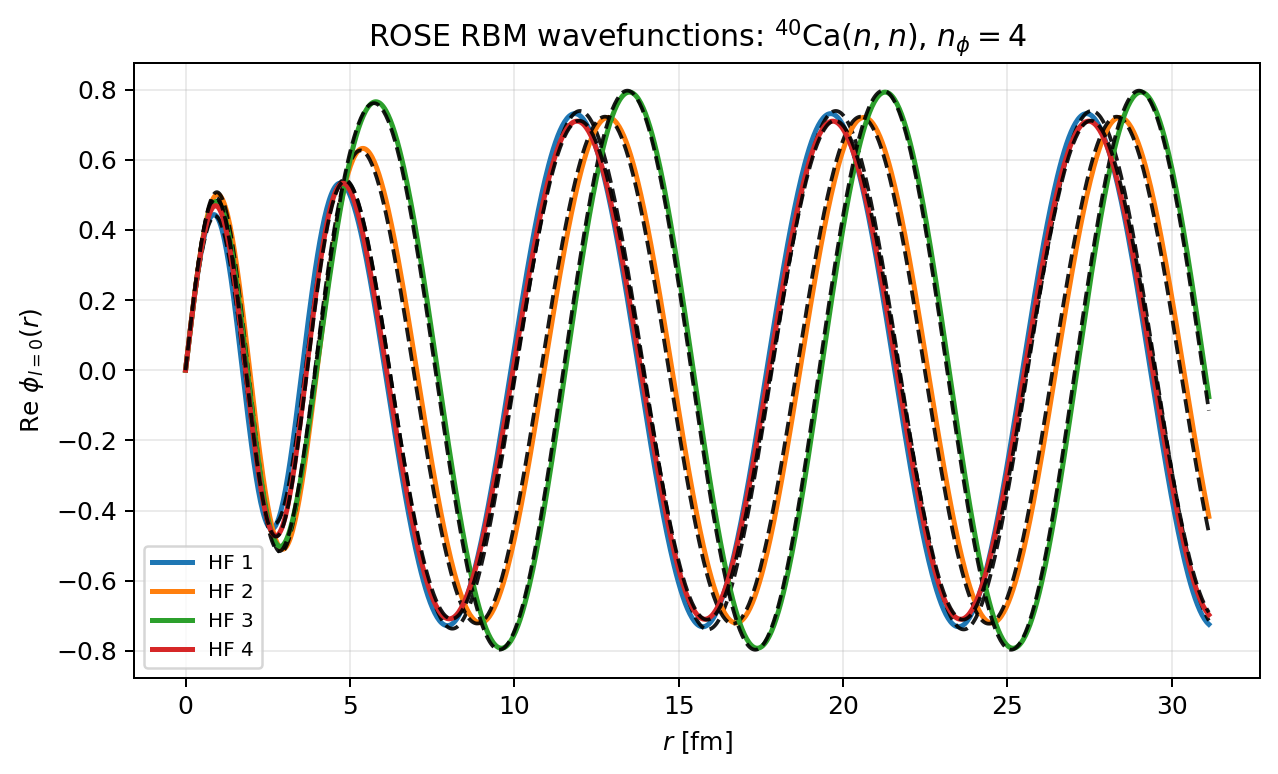

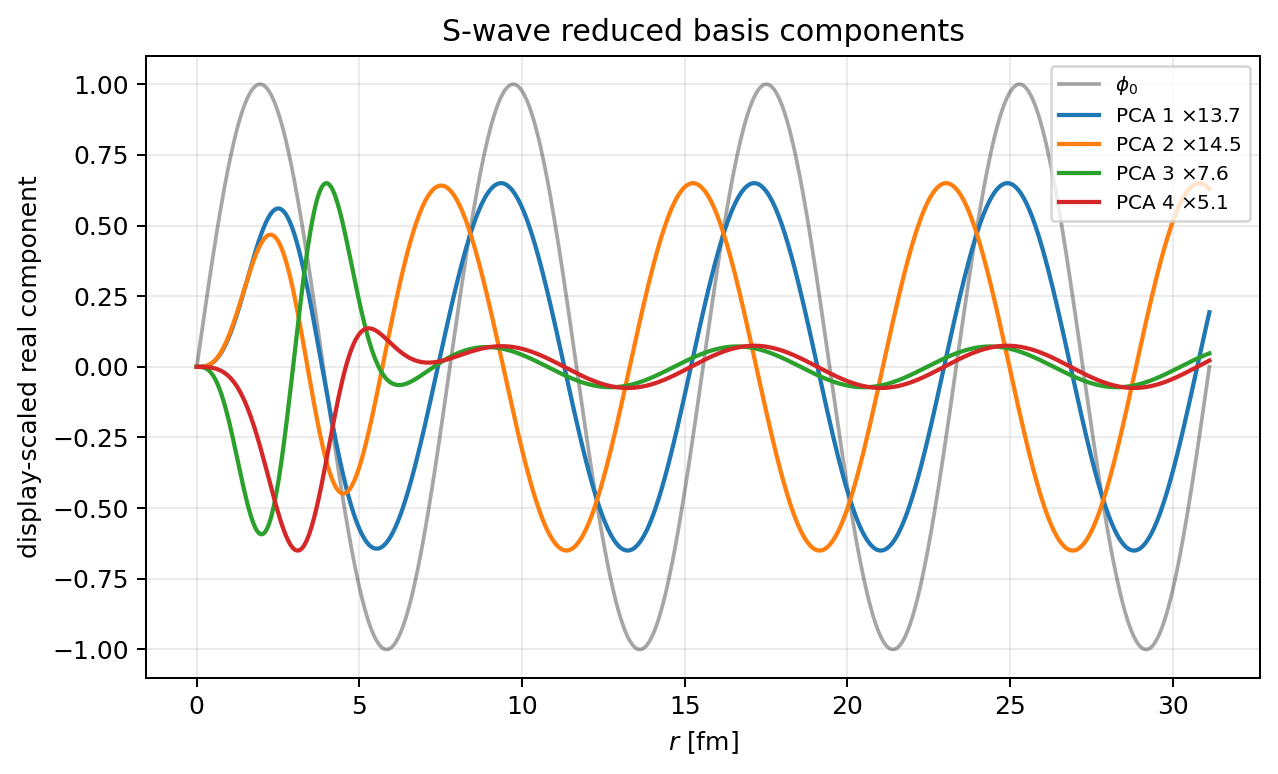

In [4]:
wave_diag = rose_rom.wavefunction_comparison(emulator, problem)
fig = wave_diag["figure"]
basis_fig = wave_diag["basis_figure"]
fig.savefig(OUT / "wavefunction_fom_vs_rose.png", dpi=180, bbox_inches="tight")
basis_fig.savefig(OUT / "s_wave_reduced_basis_components.png", dpi=180, bbox_inches="tight")
print("relative wavefunction errors:", np.array2string(wave_diag["relative_errors"], precision=3))
display(fig)
display(basis_fig)
plt.close(fig)
plt.close(basis_fig)

## Cross-Section Benchmark

The differential cross section is the final observable.  Here we compare
FOM and ROSE ROM curves for representative held-out parameter points.

max relative cross-section errors: [1.186 0.52  0.372]


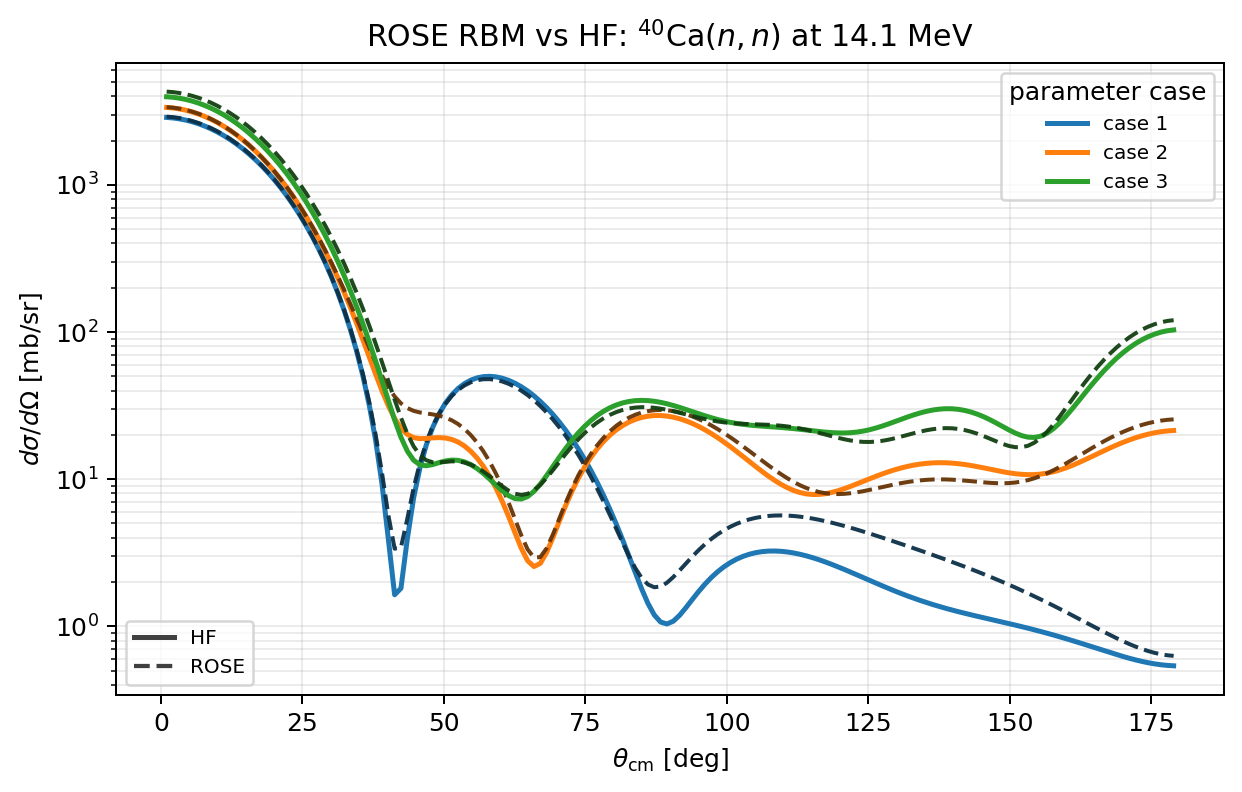

,Vv,Rv,av,Wv,Rwv,awv,Wd,Rd,ad,Vso,Rso,aso,Wso,Rwso,awso
case 1,39.854300,3.373400,0.691500,1.299000,3.440700,0.606400,8.857000,4.811200,0.635400,6.002900,3.004000,0.636800,-0.057700,3.812500,0.682700
case 2,56.555400,4.146300,0.753900,1.058500,3.760500,0.662100,7.061800,5.019800,0.560200,4.530500,4.061600,0.561100,-0.066800,3.524100,0.707500
case 3,52.169500,4.582900,0.670000,1.211100,3.538200,0.584500,6.420400,3.549300,0.534500,5.102900,3.334700,0.497700,-0.082900,4.041800,0.606200


,Vv,Rv,av,Wv,Rwv,awv,Wd,Rd,ad,Vso,Rso,aso,Wso,Rwso,awso
case 1,-18.400000,-16.800000,2.900000,10.600000,-15.100000,-9.700000,15.100000,9.200000,18.100000,9.500000,-11.800000,7.900000,17.600000,11.900000,15.700000
case 2,15.800000,2.300000,12.200000,-9.900000,-7.200000,-1.500000,-8.200000,13.900000,4.100000,-17.400000,19.200000,-4.900000,4.600000,3.400000,19.900000
case 3,6.900000,13.100000,-0.300000,3.100000,-12.700000,-13.000000,-16.600000,-19.400000,-0.600000,-6.900000,-2.100000,-15.600000,-18.400000,18.600000,2.800000


In [5]:
xs_diag = rose_rom.cross_section_comparison(emulator, problem)
fig = xs_diag["figure"]
fig.savefig(OUT / "cross_section_fom_vs_rose.png", dpi=180, bbox_inches="tight")
print("max relative cross-section errors:", np.array2string(xs_diag["cross_section_max_relative_errors"], precision=3))
display(fig)
plt.close(fig)

case_labels = [f"case {i + 1}" for i in range(len(xs_diag["chosen_indices"]))]
param_names = xs_diag["parameter_names"]
values = pd.DataFrame(
    xs_diag["case_parameter_values"],
    index=case_labels,
    columns=param_names,
)
percent = pd.DataFrame(
    xs_diag["case_parameter_percent_changes"],
    index=case_labels,
    columns=param_names,
)
display(values.round(4).style.set_caption("Selected KD parameter values for plotted cross-section cases"))
display(percent.round(1).style.set_caption("Percent change from central KD parameters"))

## What To Notice

ROSE is already a powerful ROM: it constructs wavefunction bases, an EIM
representation of the interaction, and Galerkin reduced systems.  The
LROM notebooks keep the reduced-basis representation but replace the
Galerkin-projected reduced equations with learned implicit equations.